In [1]:
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

from tb_macro.constants import (
    AGE_STRATA,
    ISO3,
    START_TIME,
    END_TIME,
    LOCAL_OUTPUT_PATH,
    OUTPUT_PATH,
    YOUNG_END_AGE,
    N_OUTPUT_SAMPLES,
    SCENARIO_PARAMS,
)
from tb_macro.epi import get_base_model, add_flows_to_model, initialise_pops
from tb_macro.inputs import (
    load_demography, 
    load_fertility, 
    load_who_outcomes, 
    get_country_pop, 
    get_single_age_pop_from_ungroups,
)
from tb_macro.demography import prepare_pop_data_for_entries
from tb_macro.outputs import (
    get_posterior_samples,
    collate_output_table,
    regroup_full_outputs,
    rerun_model_for_outputs,
    get_share_folder_file_path,
    load_sampled_outputs,
)
from tb_macro.targets import NOTIF_TARGET, LATENT_TARGET, PULM_PREV_TARGET, PREV_DECLINE_TARGET
from tb_macro.plotting import plot_outputs, plot_prior_post

plt.style.use("ggplot")
pd.options.plotting.backend = "matplotlib"

In [2]:
# Model construction
group_popsize, death_rates, age_weights = load_demography(ISO3)
fert_padded = load_fertility(ISO3)
tsr, death_in_unsucc, who_mort = load_who_outcomes(ISO3)
epi_model, disease_state, age_strat, clin_strat, infect_strat = get_base_model(START_TIME, END_TIME)
start_apops = [1000.0] * len(AGE_STRATA) # Arbitrary starting values, inflows determine growth
entry_times, entry_rates = prepare_pop_data_for_entries(group_popsize, START_TIME, sum(start_apops))
add_flows_to_model(
    epi_model, 
    disease_state,
    age_strat,
    clin_strat,
    infect_strat,
    age_weights,
    group_popsize,
    fert_padded,
    death_rates,
    tsr,
    death_in_unsucc,
    entry_times,
    entry_rates,
)
initialise_pops(epi_model, disease_state, age_strat, start_apops)

In [3]:
run_id = "20260908T2042Z"
folder = "59903314"
idata = az.from_netcdf(OUTPUT_PATH / folder / f"{run_id}.nc")
# Remote: idata = az.from_netcdf(OUTPUT_PATH / "<slurm_job_id>" / f"{run_id}.nc")
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_spread,9.176,3.670,2.941,14.535,0.481,0.166,56.0,152.0,1.11
bg_mixing,0.010,0.005,0.002,0.019,0.001,0.000,93.0,179.0,1.05
breakdown_rate,0.294,0.093,0.153,0.450,0.021,0.005,20.0,36.0,1.38
clearance_rate,0.053,0.027,0.010,0.094,0.006,0.002,16.0,14.0,1.54
clinical_progression_rate,1.568,0.523,0.799,2.602,0.100,0.079,30.0,50.0,1.21
detect_rate_current,1.053,0.209,0.736,1.488,0.032,0.012,43.0,54.0,1.14
infectiousness_gain_rate,0.202,0.072,0.101,0.324,0.008,0.004,52.0,67.0,1.12
mixing_dist_sd,13.953,3.392,8.348,19.817,0.368,0.203,60.0,21.0,1.12
pc_strength,0.499,0.261,0.080,0.903,0.028,0.011,92.0,187.0,1.06
raw_transmission_rate,15.336,2.452,11.537,19.966,0.401,0.224,38.0,55.0,1.16


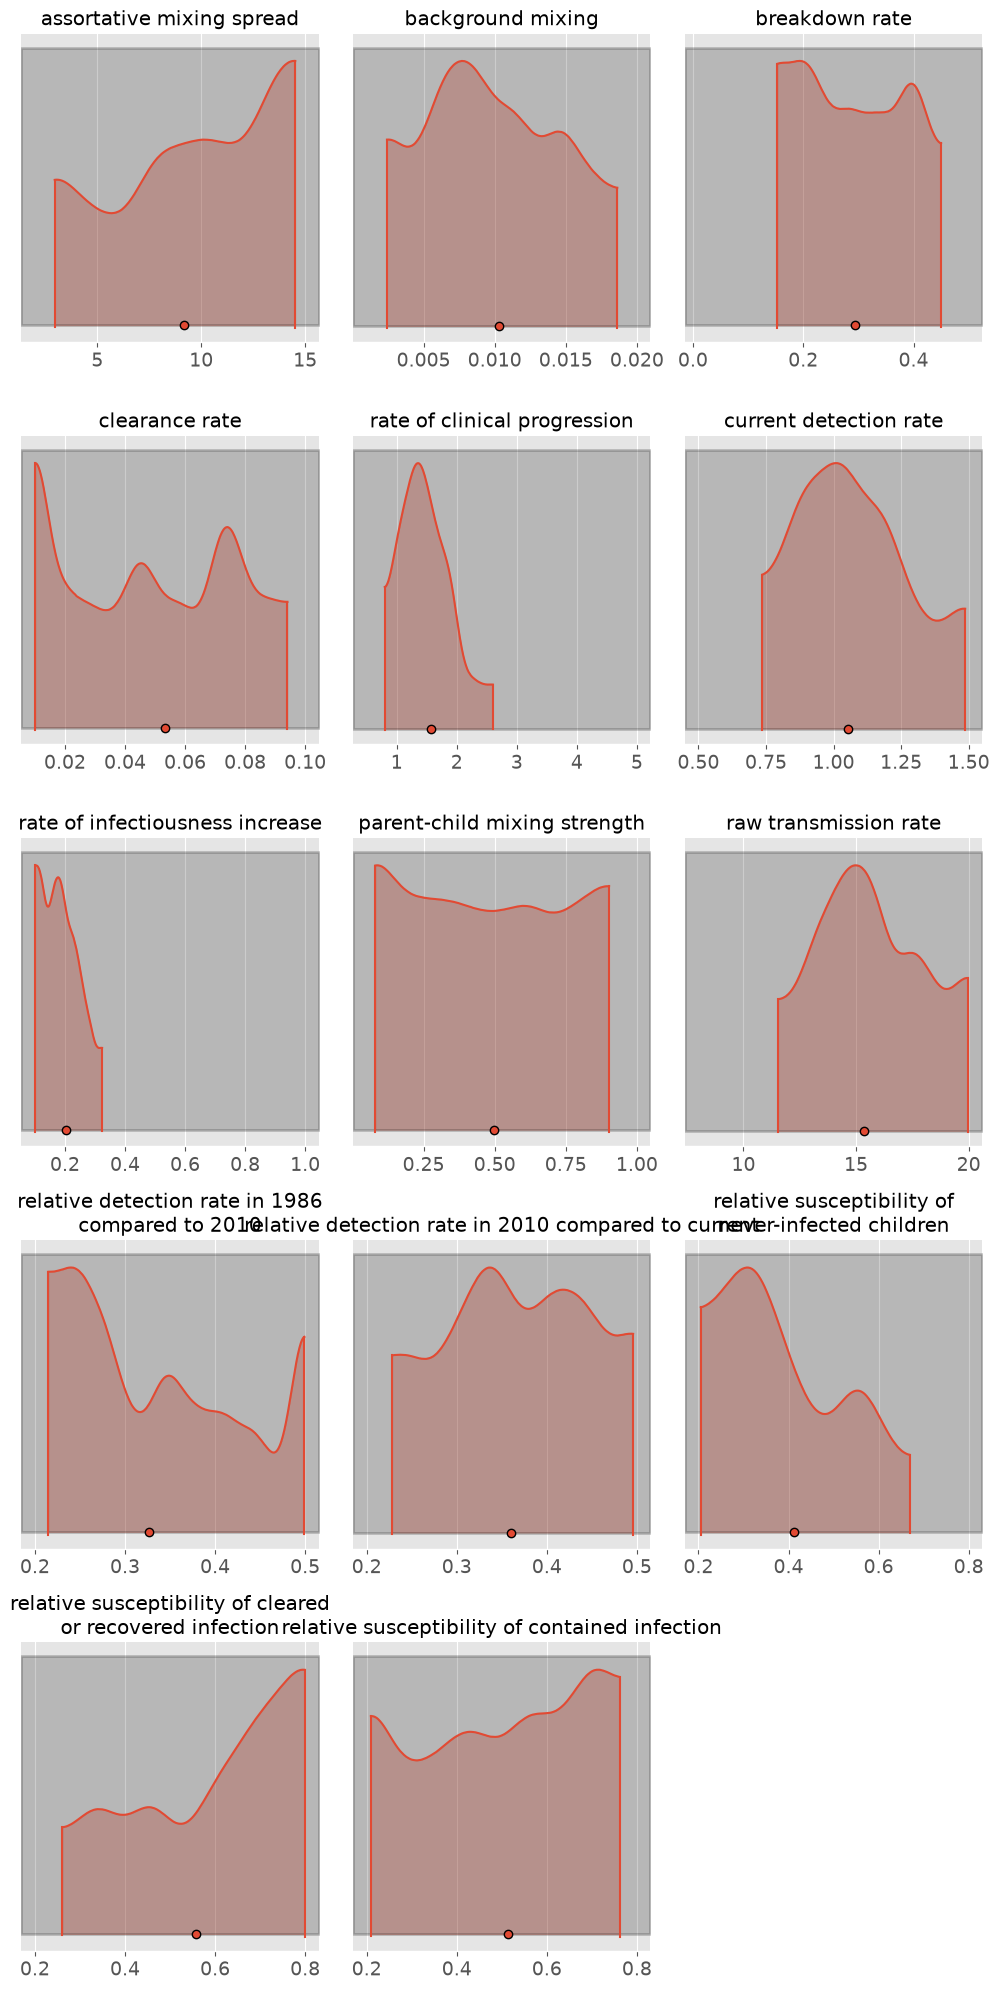

In [4]:
req_vars = [v for v in idata.posterior.data_vars if v != "mixing_dist_sd"]
plot_prior_post(idata, req_vars)

In [5]:
# Get samples
samples = get_posterior_samples(idata, N_OUTPUT_SAMPLES)

In [6]:
out_groups = range(81)

# Local: re-run posterior samples (slow)
outputs, sample_labels = rerun_model_for_outputs(
    epi_model, age_strat, disease_state, clin_strat, infect_strat, idata, SCENARIO_PARAMS, samples
)

W0909 12:51:27.086763  818592 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [7]:
single_age_pops = get_single_age_pop_from_ungroups(get_country_pop(ISO3))
regroup_out = regroup_full_outputs(outputs, single_age_pops, out_groups)

In [8]:
full_out = collate_output_table(regroup_out, sample_labels)

In [9]:
bad_samples = (full_out[(0, "age_pop")] < -1e-3).any().groupby(level="sample").any()
good_out = full_out.drop(columns=bad_samples[bad_samples].index, level="sample")

In [10]:
def sum_df_over_lower_level(df):
    return df.T.groupby(level=0).sum().T

s_plot = 0
total_pop = sum_df_over_lower_level(good_out[s_plot]["age_pop"])
incs = sum_df_over_lower_level(good_out[s_plot]["incidence"])
notifs = sum_df_over_lower_level(good_out[s_plot]["notifications"])
prevs = sum_df_over_lower_level(good_out[s_plot]["prevalence"])
tb_deaths = sum_df_over_lower_level(good_out[s_plot]["deaths"])
adult_ages = good_out[s_plot]["age_pop"].columns.get_level_values("agegroup").astype(int) >= YOUNG_END_AGE
adult_pop = sum_df_over_lower_level(good_out[s_plot]["age_pop"].loc[:, adult_ages])
pulm_prevs = sum_df_over_lower_level(good_out[s_plot]["pulm_prev"].loc[:, adult_ages])
latent = sum_df_over_lower_level(good_out[s_plot]["latent"].loc[:, adult_ages])

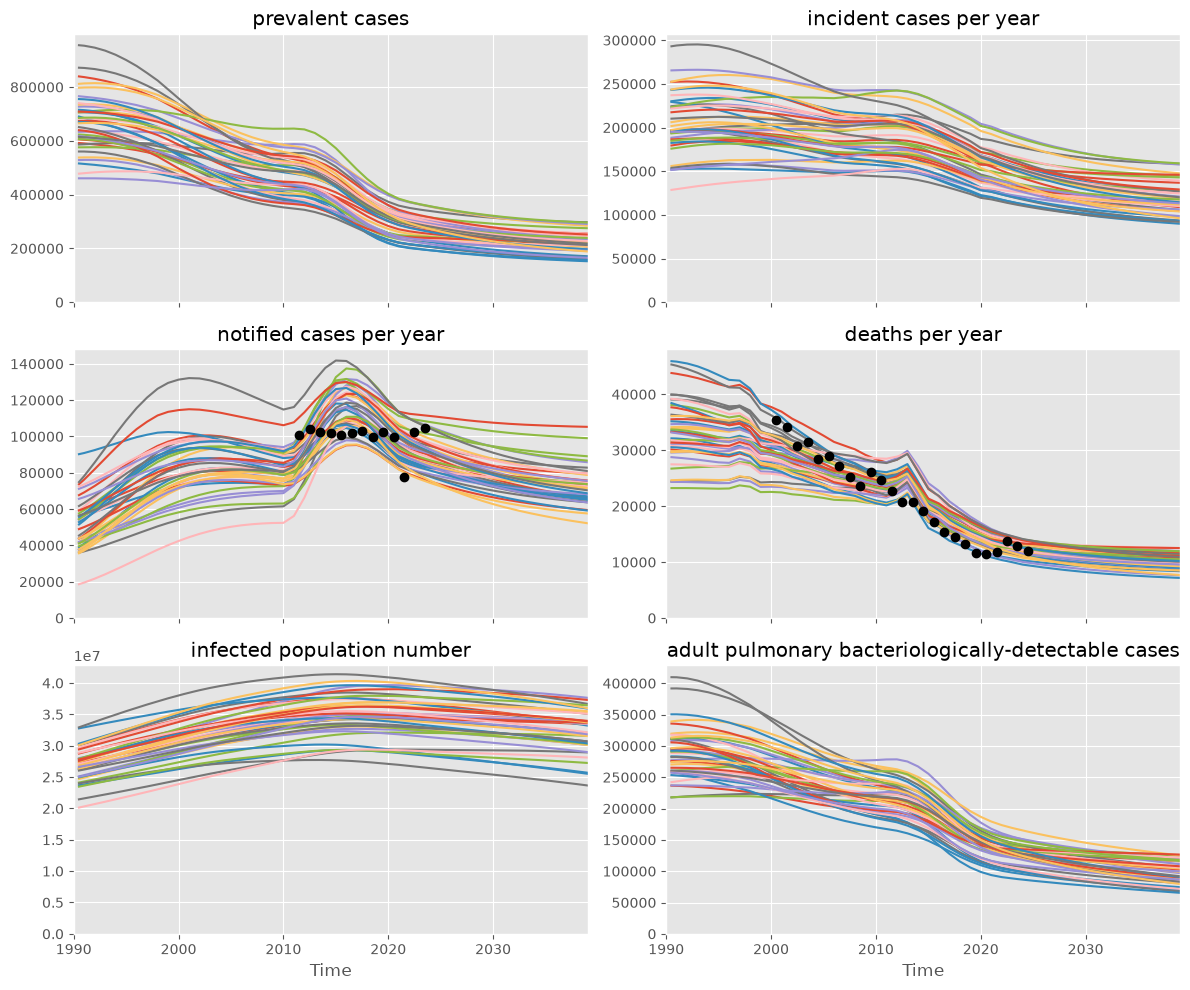

In [11]:
plot_outputs(prevs, incs, notifs, NOTIF_TARGET, tb_deaths, who_mort, latent, None, total_pop, 1990.0, 2040.0, "count", pulm_prevs, None, adult_pop)

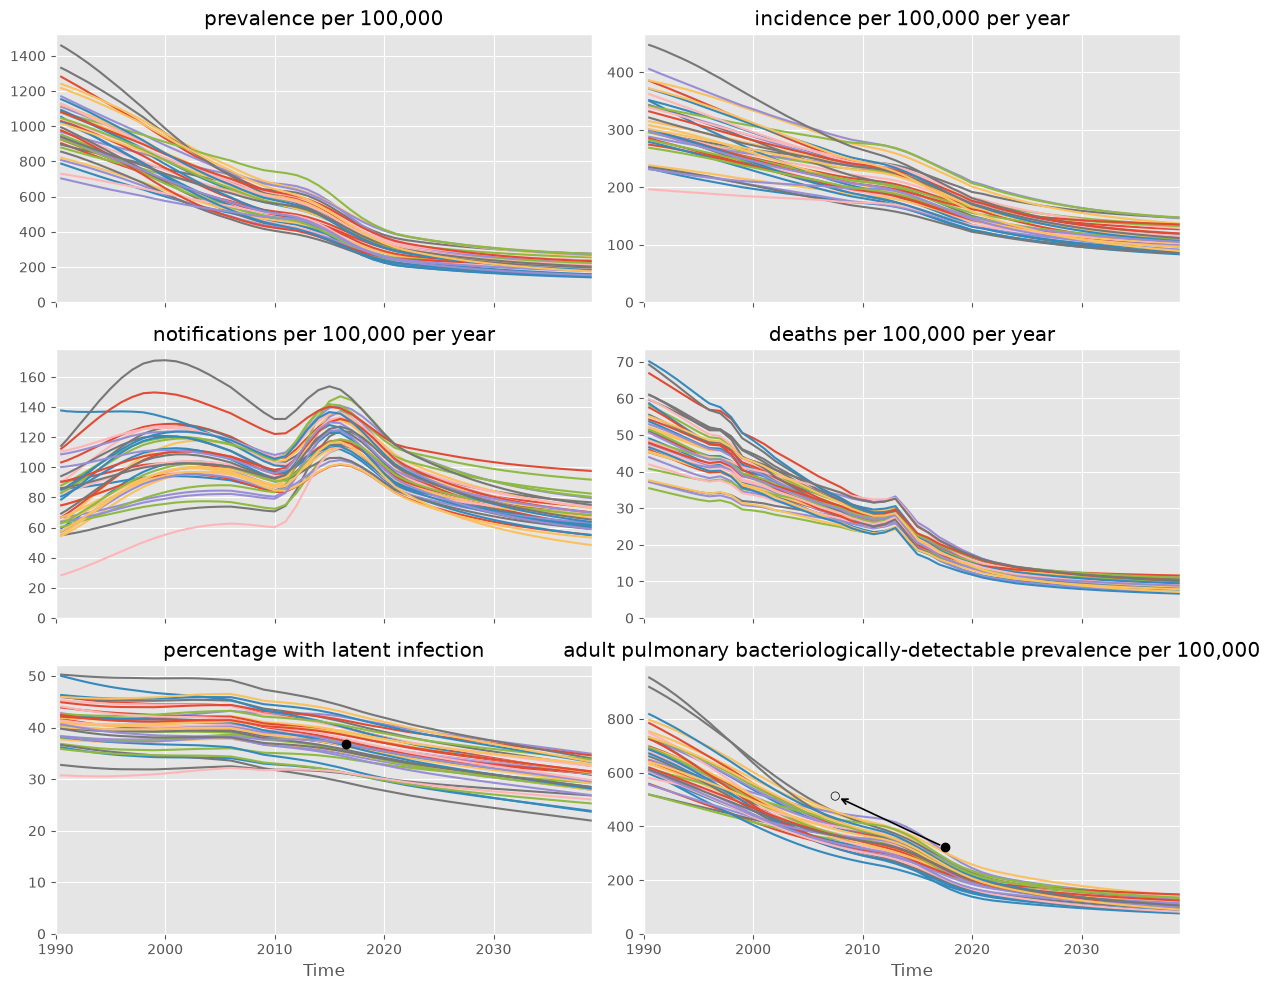

In [12]:
plot_outputs(prevs, incs, notifs, NOTIF_TARGET, tb_deaths, None, latent, LATENT_TARGET, total_pop, 1990.0, 2040.0, "rate", pulm_prevs, PULM_PREV_TARGET, adult_pop, PREV_DECLINE_TARGET)

In [13]:
# james_work_gdrive = "/Users/jamestrauer/Library/CloudStorage/GoogleDrive-james.trauer@monash.edu"
# out_path = get_share_folder_file_path(james_work_gdrive) 
# for k in good_out.columns.unique(level="scenario"):
#     scen_out = good_out[k].T
#     scen_out.to_csv(out_path / f"scen{k}_out.csv")
# idata.to_netcdf(out_path / "idata.nc")

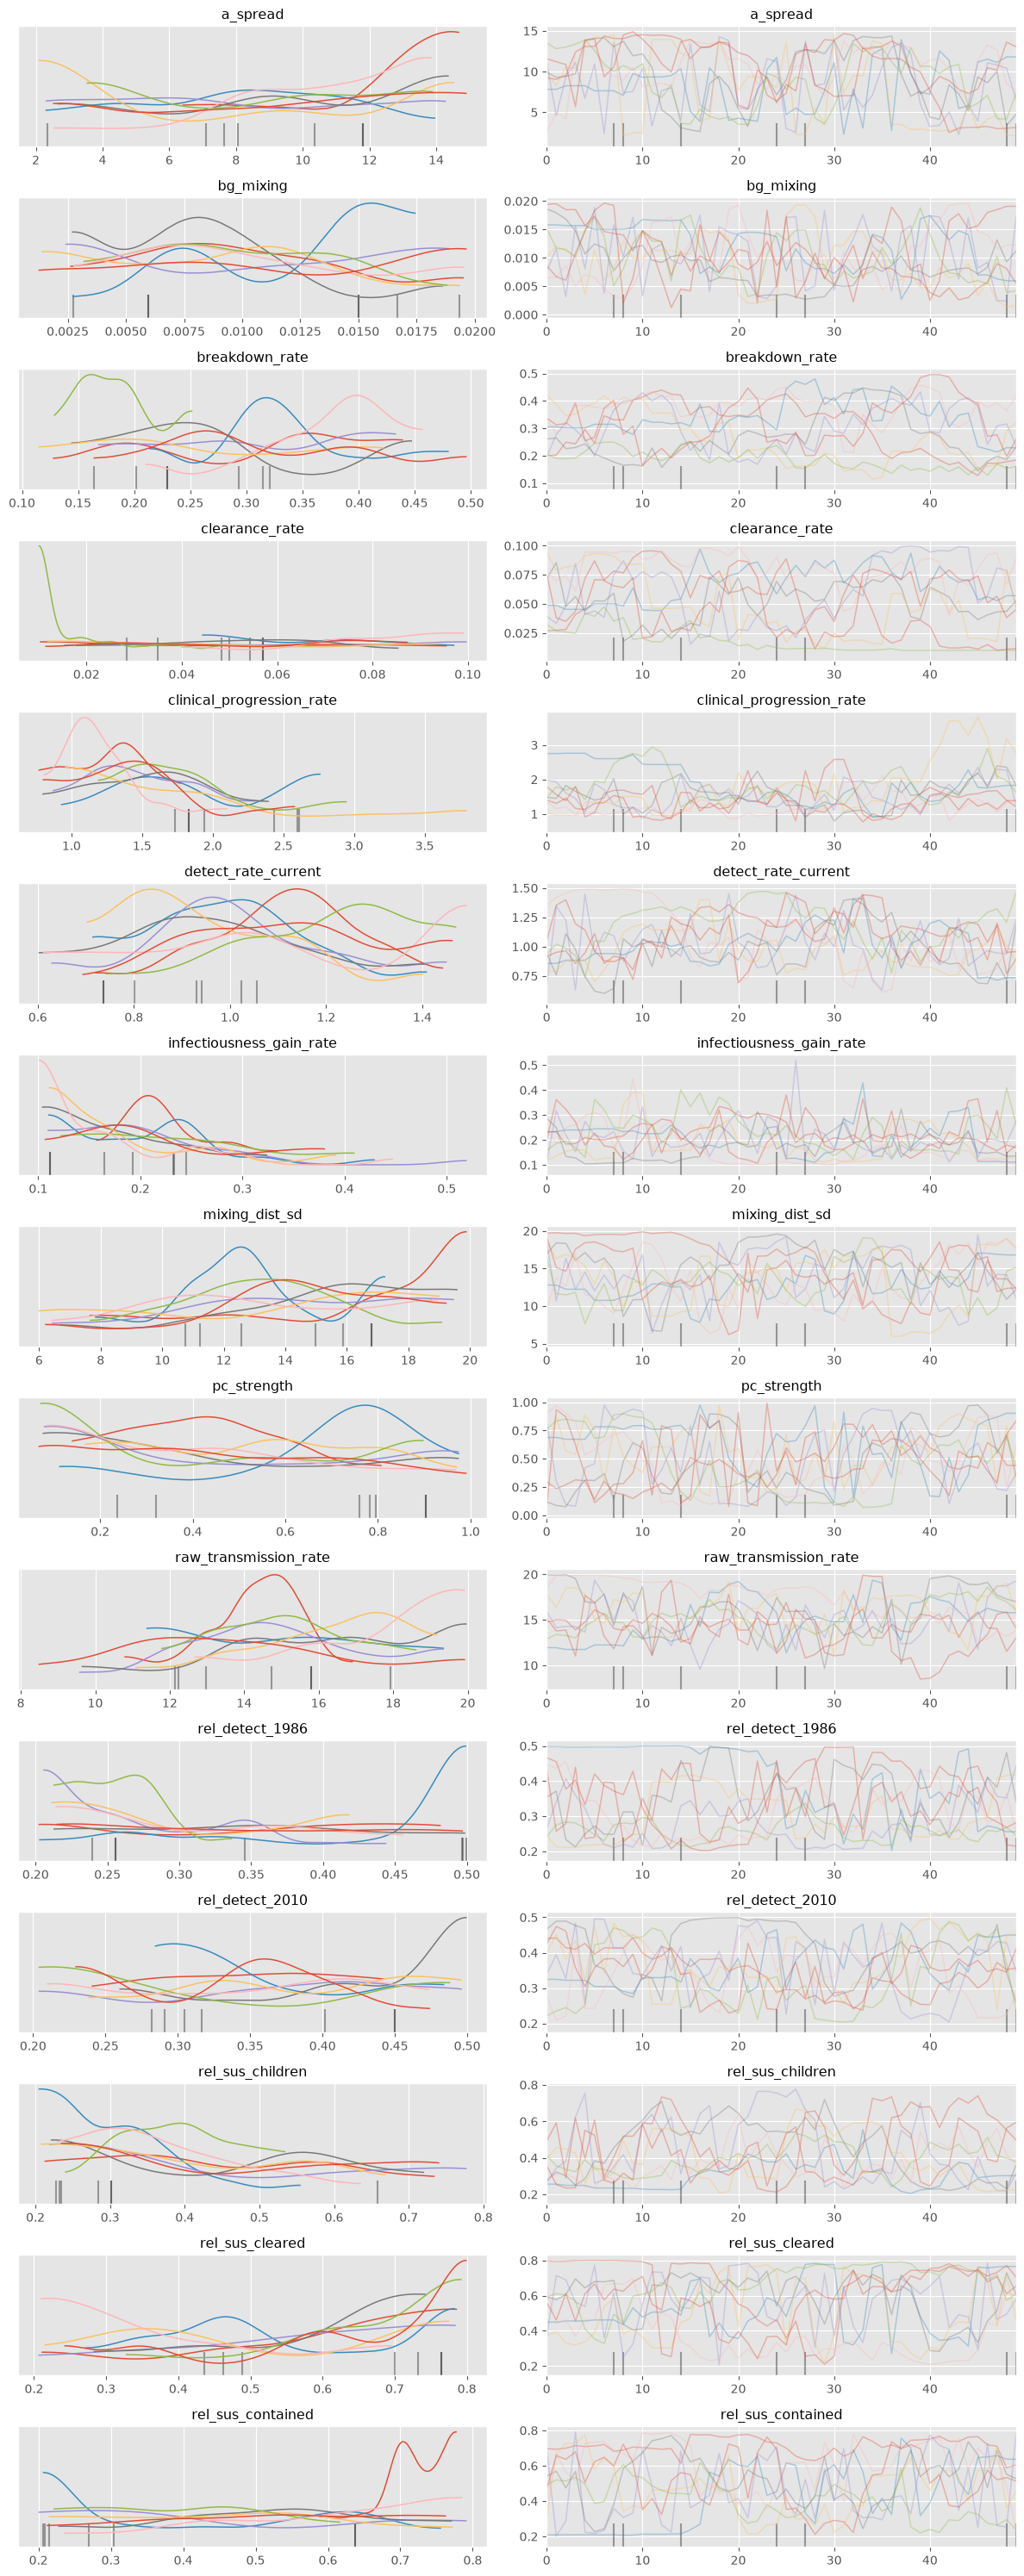

In [14]:
axes = az.plot_trace(idata, compact=False)
fig = axes[0, 0].figure
fig.tight_layout()